# 🧠 Stage 2: Baseline Model Evaluation & Collapse Diagnosis
**Project:** Reduction Ladder for Code & Multi-Arm Mitigation  
**Organization:** Orange Innovation Labs — AI Research Division  
**Authors:** Omar Abdelhamid, Nour Walid  
**Supervisor:** Dr. Ghada  

---

### 🎯 Objectives of this Notebook:
1. Load the un-tuned student model **`Qwen/Qwen2.5-Coder-1.5B-Instruct`** in **4-bit NF4 precision** (fits comfortably in 4 GB VRAM on our RTX 3070).
2. Execute deterministic **Pass@1** (greedy decoding, $T=0.0$) and **Pass@5** (nucleus sampling, $T=0.8$) across all six ladder levels (**L0 to L5**).
3. Run automated **Error Taxonomy Diagnosis** (categorizing failures into `on_path`, `off_path`, `wrong_template`, `syntax_error`, or `runtime_error`).
4. Determine the baseline **Collapse Point** ($\ell^*$) and plot the un-tuned degradation curve.

## 1. Environment Setup & Clean Architecture Imports

In [1]:
import os
import sys
import torch
import pandas as pd
import matplotlib.pyplot as plt

# Add project root to sys.path
sys.path.insert(0, os.path.abspath(".."))

from src.shared.data_service import DataService
from src.stage2_baseline.evaluation_service import EvaluationService
from src.stage5_comparison.analysis_service import AnalysisService
from src.infrastructure.hf_loader import HuggingFaceBenchmarkLoader
from src.infrastructure.model_loader import QuantizedModelRunner
from src.infrastructure.sandbox import MultiprocessSandbox
from src.infrastructure.classifier import RuleBasedErrorClassifier

print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
    print(f"Initial VRAM Allocated: {torch.cuda.memory_allocated(0)/(1024**2):.1f} MB")

print("\n✅ Clean Architecture modules imported successfully!")

c:\Users\Lenovo\anaconda3\envs\unsloth_env\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
c:\Users\Lenovo\anaconda3\envs\unsloth_env\lib\site-packages\transformers\utils\hub.py:105: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


CUDA Available: True
GPU Device: NVIDIA GeForce RTX 3070 Ti Laptop GPU
Initial VRAM Allocated: 0.0 MB

✅ Clean Architecture modules imported successfully!


## 2. Load the Reduction Ladder Benchmarks (L0 to L5)

In [2]:
data_service = DataService(loader=HuggingFaceBenchmarkLoader(cache_dir="../data/ladder"))
ladder_data = data_service.prepare_all_benchmarks(force_download=False)

for lvl, tasks in ladder_data.items():
    print(f"Level {lvl} ({tasks[0].benchmark}): {len(tasks)} tasks loaded")

Level L0 (HumanEval_Standard): 164 tasks loaded
Level L1 (EvoEval_Subtle): 100 tasks loaded
Level L2 (EvoEval_ToolUse): 100 tasks loaded
Level L3 (EvoEval_Creative): 100 tasks loaded
Level L4 (EvoEval_Difficult): 100 tasks loaded
Level L5 (EvoEval_Combine): 100 tasks loaded


## 3. Initialize Quantized Model Runner (4-bit NF4)
We load `Qwen/Qwen2.5-Coder-1.5B-Instruct` using bitsandbytes 4-bit Double Quantization to stay well within our 8 GB VRAM budget.

In [3]:
model_name = "Qwen/Qwen2.5-Coder-1.5B-Instruct"
model_runner = QuantizedModelRunner(model_name_or_path=model_name)

eval_service = EvaluationService(
    model_runner=model_runner,
    executor=MultiprocessSandbox(default_timeout=5.0),
    classifier=RuleBasedErrorClassifier()
)

if torch.cuda.is_available():
    print(f"\n🔥 Post-load VRAM Allocated: {torch.cuda.memory_allocated(0)/(1024**2):.1f} MB")

[MODEL] Loading tokenizer for 'Qwen/Qwen2.5-Coder-1.5B-Instruct' (cache: D:\hf_cache)...
[MODEL] Loading 4-bit NF4 quantized model: 'Qwen/Qwen2.5-Coder-1.5B-Instruct'...


Skipping import of cpp extensions due to incompatible torch version 2.6.0+cu124 for torchao version 0.16.0             Please see https://github.com/pytorch/ao/issues/2919 for more info
Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


[MODEL] Model successfully loaded and ready for inference.

🔥 Post-load VRAM Allocated: 1101.7 MB


## 4. Run Full Ladder Evaluation (L0 to L5)
We evaluate Pass@1 (Greedy) and diagnose error categories for every task across all 6 levels.

In [4]:
os.makedirs('../results/baseline', exist_ok=True)
output_report_file = '../results/baseline/baseline_evaluation_report.json'

# Set FORCE_RERUN = True to re-evaluate the full model across 664 tasks on GPU
FORCE_RERUN = False

if os.path.exists(output_report_file) and not FORCE_RERUN:
    print(f'📦 Found cached evaluation report at "{output_report_file}". Loading...')
    baseline_suite_report = EvaluationService.load_suite_report(output_report_file)
    print('✅ Loaded cached suite report successfully!')
else:
    print('🚀 Running full evaluation on model...')
    baseline_suite_report = eval_service.evaluate_suite(
        ladder_data=ladder_data,
        model_name='M1: Baseline (Qwen2.5-Coder-1.5B-Instruct)',
        evaluate_pass5=False,
        output_file=output_report_file
    )



[EVAL] Evaluating level: L0 (164 tasks)...


Evaluating L0:   0%|          | 0/164 [00:00<?, ?it/s]c:\Users\Lenovo\anaconda3\envs\unsloth_env\lib\site-packages\transformers\generation\configuration_utils.py:631: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
c:\Users\Lenovo\anaconda3\envs\unsloth_env\lib\site-packages\transformers\generation\configuration_utils.py:636: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
c:\Users\Lenovo\anaconda3\envs\unsloth_env\lib\site-packages\transformers\generation\configuration_utils.py:653: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
 

[EVAL] L0 Result: Pass@1 = 92.68%
[EVAL] Error Breakdown: {'runtime_error': 9, 'pass': 152, 'timeout': 2, 'on_path': 1}

[EVAL] Evaluating level: L1 (100 tasks)...


Evaluating L1: 100%|██████████| 100/100 [11:36:30<00:00, 417.90s/it]   


[EVAL] L1 Result: Pass@1 = 89.00%
[EVAL] Error Breakdown: {'pass': 89, 'runtime_error': 9, 'wrong_template': 1, 'syntax_error': 1}

[EVAL] Evaluating level: L2 (100 tasks)...


...

[EVAL] L3 Result: Pass@1 = 75.00%
[EVAL] Error Breakdown: {'pass': 75, 'runtime_error': 17, 'on_path': 7, 'syntax_error': 1}

[EVAL] Evaluating level: L4 (100 tasks)...


Evaluating L4: 100%|██████████| 100/100 [1:09:34<00:00, 41.75s/it]


[EVAL] L4 Result: Pass@1 = 77.00%
[EVAL] Error Breakdown: {'pass': 77, 'on_path': 4, 'runtime_error': 18, 'timeout': 1}

[EVAL] Evaluating level: L5 (100 tasks)...


Evaluating L5: 100%|██████████| 100/100 [1:05:01<00:00, 39.02s/it]

[EVAL] L5 Result: Pass@1 = 79.00%
[EVAL] Error Breakdown: {'pass': 79, 'runtime_error': 13, 'syntax_error': 5, 'on_path': 1, 'wrong_template': 2}
[SAVE] Full evaluation report saved to '../results/baseline/baseline_evaluation_report.json'.


## 5. Metrics Summary & Collapse Point Determination

In [5]:
results_dict = {
    "M1: Baseline": {
        "ladder_auc": baseline_suite_report.ladder_auc,
        "collapse_point": baseline_suite_report.collapse_point,
        "consistency_delta": baseline_suite_report.consistency_delta,
        "level_reports": {
            k: {"pass_at_1": v.pass_at_1, "error_breakdown": v.error_breakdown}
            for k, v in baseline_suite_report.level_reports.items()
        }
    }
}

summary_table = AnalysisService.compute_summary_table(results_dict)
summary_table

,Model,L0 (HumanEval),L1 (Subtle),L2 (ToolUse),L3 (Creative),L4 (Difficult),L5 (Combine),Ladder AUC,Collapse Point,Consistency Delta
0,M1: Baseline,92.7%,89.0%,93.0%,75.0%,77.0%,79.0%,84.3%,None (Maintained > 50%),4.0%


## 6. Plot the Baseline Degradation Curve

[PLOT] Saved comparative degradation plot to '../results/baseline/baseline_degradation_curve.png'.


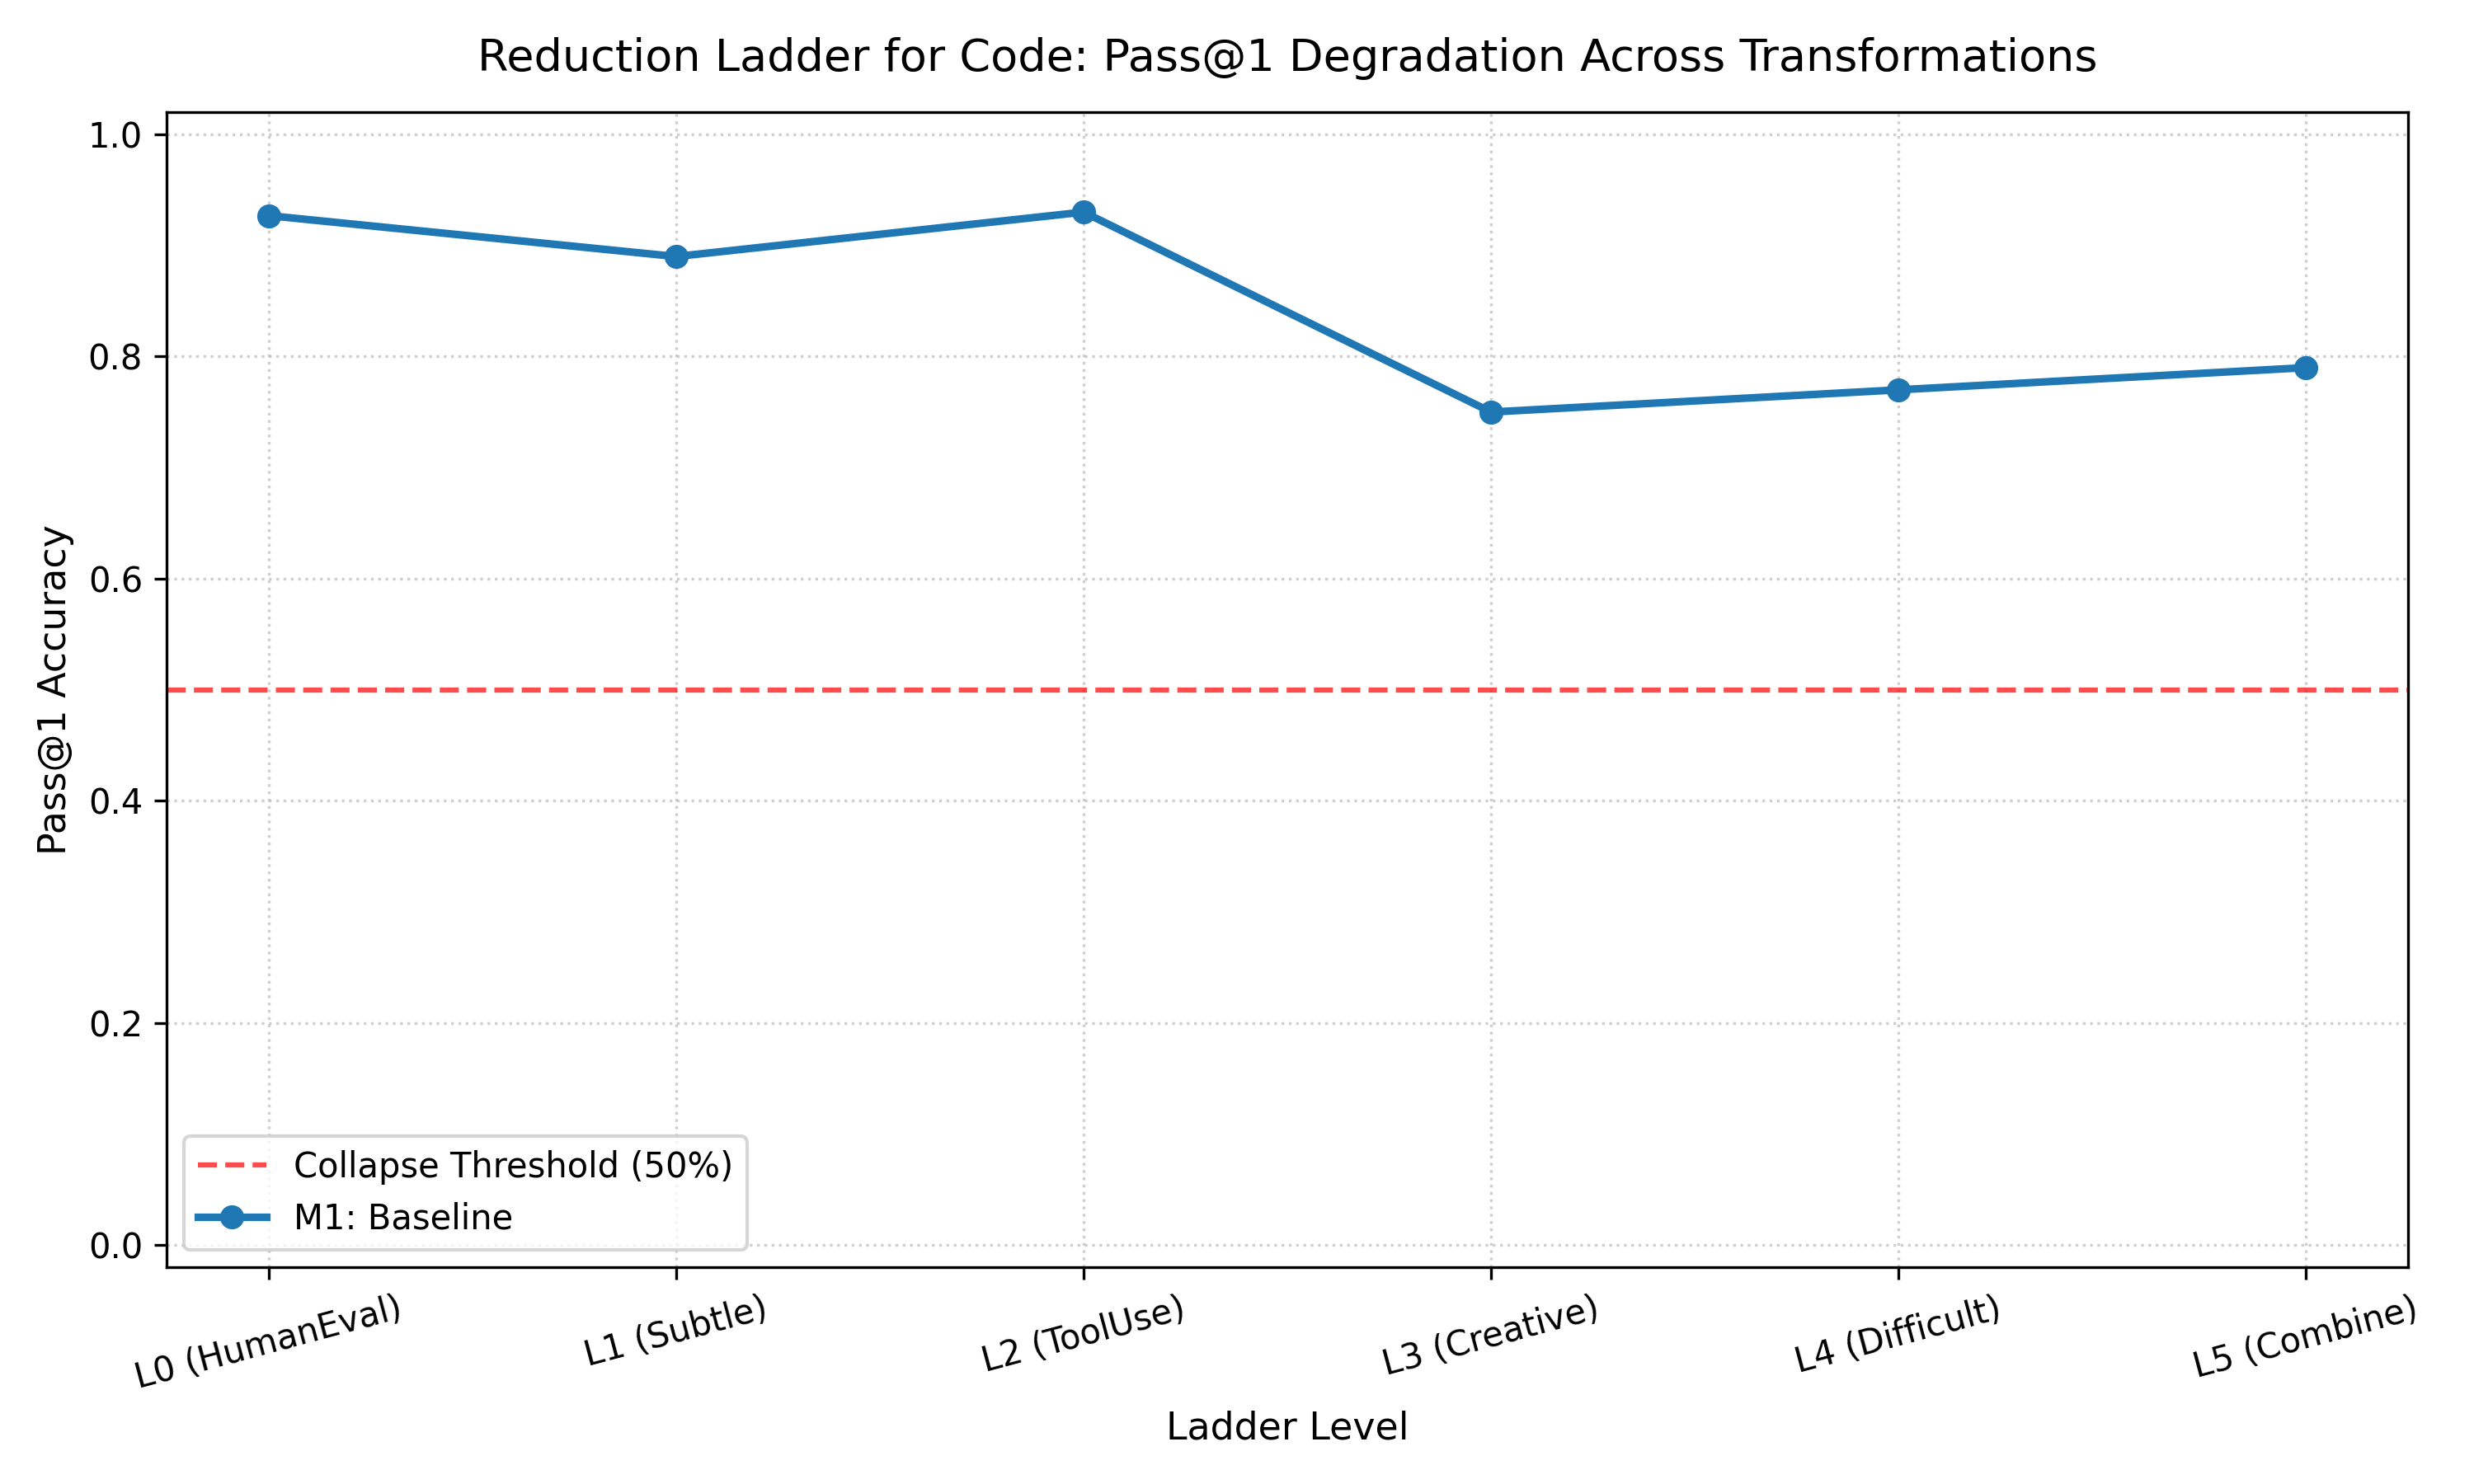

In [6]:
AnalysisService.plot_ladder_curves(
    suite_reports=results_dict,
    output_filepath="../results/baseline/baseline_degradation_curve.png"
)

# Display plot inside notebook
from IPython.display import Image
Image("../results/baseline/baseline_degradation_curve.png")

## 7. Error Taxonomy Breakdown Across Levels
Let's inspect what types of errors caused the collapse at higher ladder levels (e.g. wrong template vs on-path vs off-path).

📊 Error Counts by Category:


,runtime_error,pass,timeout,on_path,wrong_template,syntax_error
Level,,,,,,
L0,9,152,2.0,1.0,0.0,0.0
L1,9,89,0.0,0.0,1.0,1.0
L2,3,93,1.0,1.0,0.0,2.0
L3,17,75,0.0,7.0,0.0,1.0
L4,18,77,1.0,4.0,0.0,0.0
L5,13,79,0.0,1.0,2.0,5.0


<Figure size 1500x750 with 0 Axes>

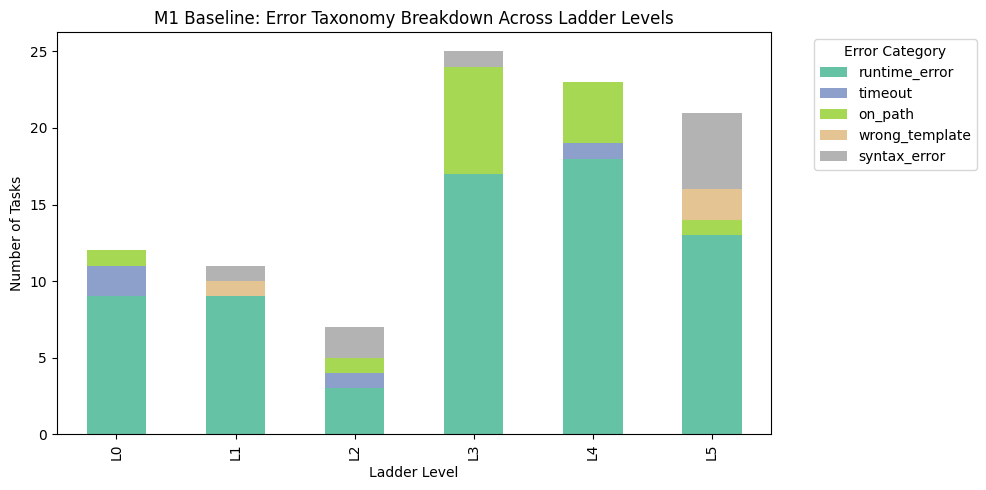

In [7]:
error_records = []
for lvl, rep in baseline_suite_report.level_reports.items():
    breakdown = rep.error_breakdown.copy()
    breakdown['Level'] = lvl
    error_records.append(breakdown)

error_df = pd.DataFrame(error_records).set_index('Level').fillna(0)
print('📊 Error Counts by Category:')
display(error_df)

# Plot Stacked Error Distribution
ax = error_df.drop(columns=['pass'], errors='ignore').plot(
    kind='bar',
    stacked=True,
    colormap='Set2',
    figsize=(10, 5)
)
plt.title('M1 Baseline: Error Taxonomy Breakdown Across Ladder Levels', fontsize=12)
plt.xlabel('Ladder Level', fontsize=11)
plt.ylabel('Number of Tasks', fontsize=11)
plt.legend(title='Error Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../results/baseline/baseline_error_taxonomy.png', dpi=300)
plt.show()


## 8. Inspect Concrete Failure Examples (Template Recalls)
Let's print specific tasks from L2/L3 where the model failed due to `wrong_template` or `off_path` errors.

In [8]:
for lvl in ["L1", "L2", "L3"]:
    if lvl in baseline_suite_report.level_reports:
        rep = baseline_suite_report.level_reports[lvl]
        failures = [t for t in rep.task_results if not t["p1_passed"]]
        if failures:
            sample = failures[0]
            print(f"\n{'='*30} Sample Failure in {lvl} (Task ID: {sample['task_id']}) {'='*30}")
            print(f"Diagnosis: {sample['p1_error_category']}")
            print(f"Error Message: {sample['p1_error_message']}")
            print("Generated Code Snippet:")
            print(sample["p1_code"][:400] + "...")


============================== Sample Failure in L1 (Task ID: EvoEval/5) ==============================
Diagnosis: runtime_error
Error Message: Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "<string>", line 39, in <module>
  File "<string>", line 29, in intersperse
NameError: name 'delimiter' is not defined. Did you mean: 'delimeter'?
Generated Code Snippet:
from typing import List

def intersperse(numbers: List[int], delimeter: int) -> List[int]:
    """ Insert a number 'delimeter' between every two consecutive elements of input list `numbers' and add 'delimeter' at the end of the list
    >>> intersperse([], 4)
    [4]
    >>> intersperse([1, 2, 3], 4)
    [1, 4, 2, 4, 3, 4]
    """
    if not numbers:
        return [delimeter]
    
    result = []...

============================== Sample Failure in L2 (Task ID: EvoEval/0) ==============================
Diagnosis: timeout
Error Message: Execution exceeded timeout limit (5.0s)
Generated Code Snipp